<a href="https://colab.research.google.com/github/Joemulberry-acoust/Machine-Learning-Seminar/blob/main/mlzemi_0604.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

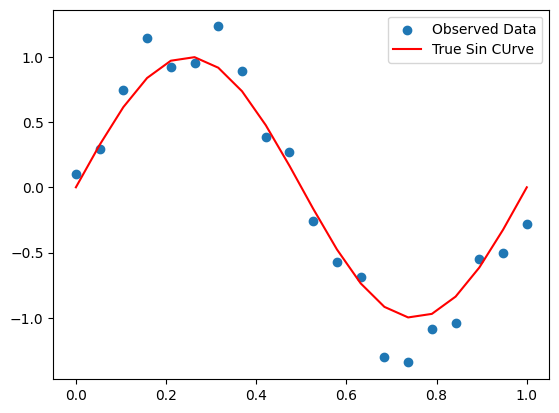

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. データの準備（Xの値を決める）
x = np.linspace(0, 1, 20) #0から1の間に20個の点を作る

# 2. 本来の関数を決める：sinカーブに少しノイズを混ぜる
# 「関数を見つけてね！」と出題する準備
true_y = np.sin(2 * np.pi * x) #xが0から1まで動くのに一周（2π）

# 3. ノイズを混ぜてデータをサンプリング（観測データ作る）
# 実際のデータは、きれいな線から少しずれていることを再現
np.random.seed(42) # 毎回同じ結果になるように固定
noise = np.random.normal(0, 0.2, size=x.shape) # 0を中心に±0.2くらいのばらつき
t = true_y + noise # 理論上の正解にノイズを足し合わせ、実際に観測される観測地を作る

# 4. グラフで表示
plt.scatter(x, t, label='Observed Data') # 観測データ
plt.plot(x, true_y, color='red', label='True Sin CUrve') # 本来の線
plt.legend() # 説明書き
plt.show() # これまで書いた絵を表示


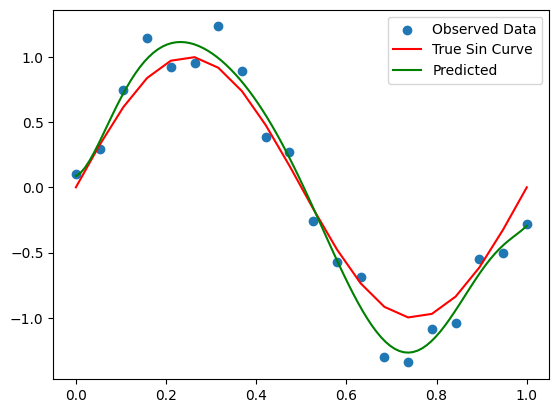

In [ ]:
# 1. データを当てはめる準備：多項式の係数を求める
# 9次の多項式で曲線を当てはめてみる
degree = 9
# numpy.polyfit は、データに最もフィットする多項式の係数を計算する関数
z = np.polyfit(x, t, degree)

# 2. 求めた係数を使って、予測曲線を作成する
p = np.poly1d(z) # 係数から関数をつくる
x_plot = np.linspace(0,1, 100) #グラフを滑らかにするため、点を細かく取る
y_plot = p(x_plot)

# 3. 結果をグラフにする
plt.scatter(x, t, label='Observed Data') #観測データ
plt.plot(x, true_y, color='red', label='True Sin Curve')
plt.plot(x_plot, y_plot, color='green', label='Predicted') #AIが導き出した曲線
plt.legend()
plt.show()


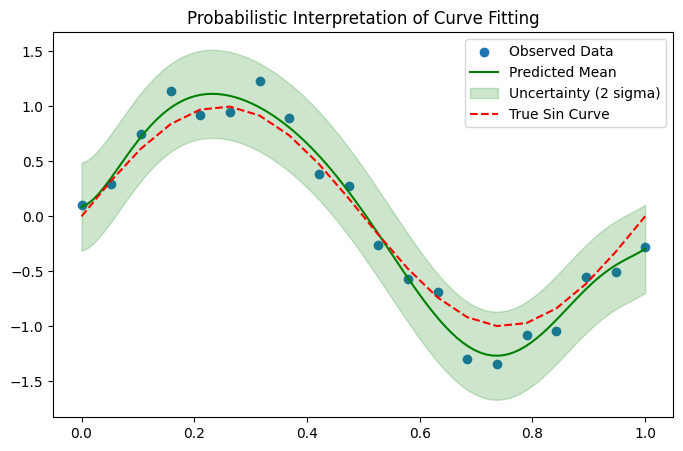

In [ ]:
# 1. 予測の不確かさを計算
# 予測のバラつきを考慮して、±2σの帯を描く
sigma = 0.2 # ノイズの大きさ（さっき決めたもの）
y_upper = y_plot + 2 * sigma
y_lower = y_plot - 2 * sigma

# 2. グラフを描画
plt.figure(figsize=(8, 5))
plt.scatter(x, t, label='Observed Data')
plt.plot(x_plot, y_plot, color='green', label='Predicted Mean')

# 予測の不確かさを「帯」として塗る
plt.fill_between(x_plot, y_lower, y_upper, color='green', alpha=0.2, label='Uncertainty (2 sigma)')
plt.plot(x, true_y, color='red', linestyle='--', label='True Sin Curve')
plt.legend()
plt.title("Probabilistic Interpretation of Curve Fitting")
plt.show()

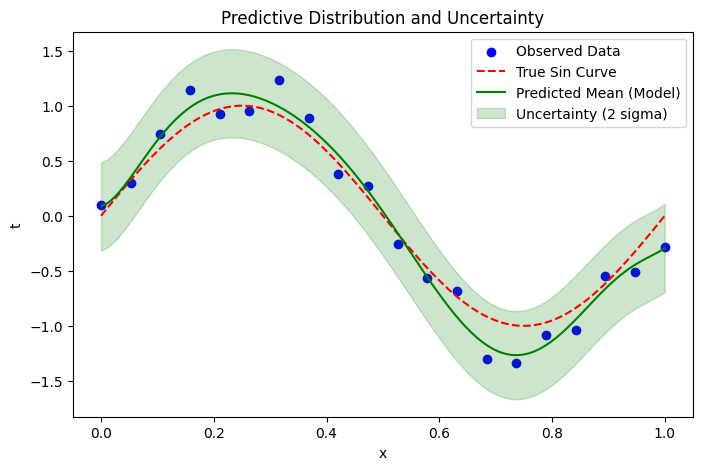

In [ ]:
# 1. 予測の平均値と、不確かさ（標準偏差）の計算
# 今回はシンプルに、学習データのノイズレベルをベースにした「帯」を描く
# 実際には、ベイジアン回帰などを使うとこの帯は自動的に計算されます

# パラメータ設定
sigma = 0.2 # 推定したノイズの大きさ
std_dev = sigma * 2 # ±2σの範囲（約95%のデータが含まれる範囲）

# 平均値（緑の線）
y_plot = p(x_plot)

# 不確かさの帯の上下限
y_upper = y_plot + std_dev
y_lower = y_plot - std_dev

# 2. グラフの描画
plt.figure(figsize=(8, 5))

# 観測データ
plt.scatter(x, t, color='blue', label='Observed Data')

# 正解の関数
plt.plot(x_plot, np.sin(2 * np.pi * x_plot), color='red', linestyle='--', label='True Sin Curve')

# AIの予測平均
plt.plot(x_plot, y_plot, color='green', label='Predicted Mean (Model)')

# 不確かさの帯（fill_betweenで塗りつぶす）
plt.fill_between(x_plot, y_lower, y_upper, color='green', alpha=0.2, label='Uncertainty (2 sigma)')

plt.legend()
plt.title("Predictive Distribution and Uncertainty")
plt.xlabel("x")
plt.ylabel("t")
plt.show()